<a href="https://colab.research.google.com/github/gburv25-collab/L4-Data-Analysis/blob/main/Week6_Regression_Stretch_Colab_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression Stretch Activity — Revised Version
## Simple Linear Regression in Python

**Dataset:** `IBM_HR_Analytics.csv`  
**Stretch focus:** using one numerical variable to model a relationship with another numerical variable.

This activity extends the Week 2 work on relationships, associations and two-group differences. It introduces simple linear regression as a stretch task before the main regression session.

Regression can support prediction and modelling, but it does **not** prove causation without an appropriate research design.

### Stretch aim

By the end of this notebook, you should be able to:

- explain when regression may be more suitable than correlation
- fit a simple linear regression model in Python
- interpret the slope, intercept, p-value and R-squared
- check key regression assumptions using simple diagnostics
- interpret prediction error using MAE and RMSE
- write a cautious business-focused interpretation


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


## 2. Load the Dataset

Upload `IBM_HR_Analytics.csv` into Google Colab before running this cell.


In [ ]:
df = pd.read_csv('IBM_HR_Analytics.csv')

display(df.head())
df.info()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 3. Correlation or Regression?

Correlation and regression are related, but they are not the same.

| Method | Main purpose | Example |
|---|---|---|
| Correlation | Measures the strength and direction of association between two variables | Are TotalWorkingYears and MonthlyIncome associated? |
| Regression | Models how an outcome changes as a predictor changes | How does predicted MonthlyIncome change as TotalWorkingYears increases? |

In this notebook, regression is used as an **exploratory modelling example**. It does not prove that working years cause higher income.


## 4. Choose Variables

For this stretch activity, we will model:

- **Predictor / X:** `TotalWorkingYears`
- **Outcome / Y:** `MonthlyIncome`

This is suitable for a simple linear regression demonstration because both variables are numerical.

**Important:** Regression uses predictor/outcome language. Correlation should usually use Variable 1 and Variable 2 because correlation is symmetrical.


In [ ]:
regression_data = df[['TotalWorkingYears', 'MonthlyIncome']].dropna()

display(regression_data.head())
display(regression_data.describe())
print(regression_data.dtypes)


,TotalWorkingYears,MonthlyIncome
0,8,5993
1,10,5130
2,7,2090
3,8,2909
4,6,3468


,TotalWorkingYears,MonthlyIncome
count,"1,470.000","1,470.000"
mean,11.280,"6,502.931"
std,7.781,"4,707.957"
min,0.000,"1,009.000"
25%,6.000,"2,911.000"
50%,10.000,"4,919.000"
75%,15.000,"8,379.000"
max,40.000,"19,999.000"


TotalWorkingYears    int64
MonthlyIncome        int64
dtype: object


## 5. Core Linear Regression Assumptions

Before interpreting a regression model, consider these assumptions:

| Assumption | Simple meaning | How we check it here |
|---|---|---|
| Linearity | A straight-line model is reasonable | Scatter plot and residual plot |
| Independence | Observations/errors are independent | Consider the data design and context |
| Normality of residuals | Residuals are approximately normal for inference | Histogram and Q-Q plot of residuals |
| Constant variance | Residual spread is roughly even across fitted values | Residuals vs fitted plot |
| Influential points | No single point is overly driving the model | Cook's distance |

These checks do not need to be perfect for a stretch activity, but they should be considered before writing conclusions.


## 6. Visualise the Relationship

A scatter plot helps us check whether a straight-line model is reasonable.

Look for:

- an overall upward or downward pattern
- a roughly linear shape
- possible outliers
- unusual clusters or gaps


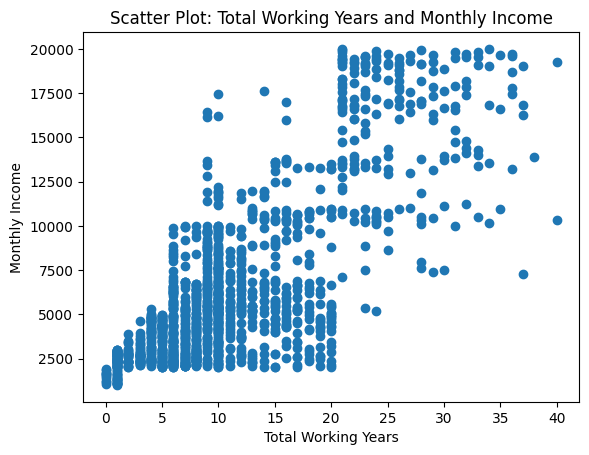

In [ ]:
plt.scatter(regression_data['TotalWorkingYears'], regression_data['MonthlyIncome'])
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.title('Scatter Plot: Total Working Years and Monthly Income')
plt.show()


## 7. Fit a Simple Linear Regression Model

The model is:

`MonthlyIncome = b0 + b1(TotalWorkingYears)`

Where:

- `b0` is the intercept
- `b1` is the slope / coefficient for `TotalWorkingYears`

The slope tells us the expected change in MonthlyIncome for a one-unit increase in TotalWorkingYears.


In [ ]:
X = regression_data['TotalWorkingYears']
y = regression_data['MonthlyIncome']

# Add a constant so the model includes an intercept, b0
X_with_constant = sm.add_constant(X)

model = sm.OLS(y, X_with_constant).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          MonthlyIncome   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.597
Method:                 Least Squares   F-statistic:                     2178.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):          2.73e-292
Time:                        19:39:26   Log-Likelihood:                -13848.
No. Observations:                1470   AIC:                         2.770e+04
Df Residuals:                    1468   BIC:                         2.771e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1227.9353    137.29

## 8. Extract Key Results

The full regression output contains a lot of information. These are the main values to interpret at this level.

| Statistic | Meaning |
|---|---|
| Intercept, b0 | Predicted value of the outcome when X = 0 |
| Slope, b1 | Expected change in the outcome for a one-unit increase in X |
| p-value for slope | Evidence about whether the slope differs from zero |
| R-squared | Proportion of variance in the outcome explained by the model |
| N | Number of observations used in the model |


In [ ]:
b0 = model.params['const']
b1 = model.params['TotalWorkingYears']
p_value_slope = model.pvalues['TotalWorkingYears']
r_squared = model.rsquared
n = int(model.nobs)

results_table = pd.DataFrame({
    'Statistic': ['Intercept, b0', 'Slope, b1', 'p-value for slope', 'R-squared', 'N'],
    'Value': [b0, b1, p_value_slope, r_squared, n]
})

display(results_table)


,Statistic,Value
0,"Intercept, b0","1,227.935"
1,"Slope, b1",467.658
2,p-value for slope,0.000
3,R-squared,0.597
4,N,"1,470.000"


## 9. Add the Regression Line

The regression line shows the predicted outcome values from the model.

The points are the observed data. The line is the model's estimated average relationship.


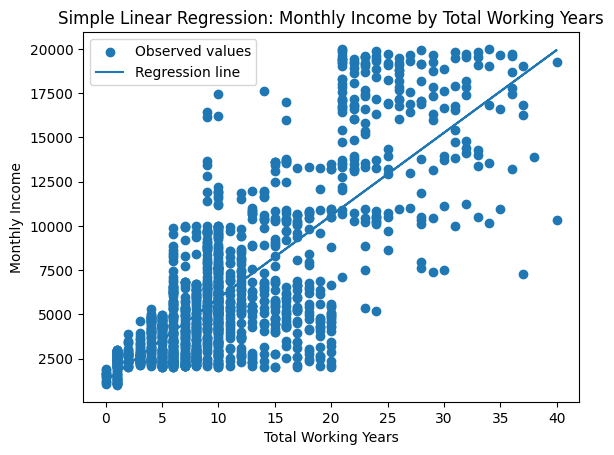

In [ ]:
predicted_income = model.predict(X_with_constant)

plt.scatter(regression_data['TotalWorkingYears'], regression_data['MonthlyIncome'], label='Observed values')
plt.plot(regression_data['TotalWorkingYears'], predicted_income, label='Regression line')
plt.xlabel('Total Working Years')
plt.ylabel('Monthly Income')
plt.title('Simple Linear Regression: Monthly Income by Total Working Years')
plt.legend()
plt.show()


## 10. Residuals: What Are They?

A residual is the difference between the observed value and the predicted value.

`Residual = Observed value - Predicted value`

Residual checks help us decide whether the straight-line model is a reasonable fit.


In [ ]:
residuals = model.resid
fitted_values = model.fittedvalues

diagnostic_data = regression_data.copy()
diagnostic_data['PredictedMonthlyIncome'] = fitted_values
diagnostic_data['Residual'] = residuals

display(diagnostic_data.head())


,TotalWorkingYears,MonthlyIncome,PredictedMonthlyIncome,Residual
0,8,5993,"4,969.203","1,023.797"
1,10,5130,"5,904.519",-774.519
2,7,2090,"4,501.544","-2,411.544"
3,8,2909,"4,969.203","-2,060.203"
4,6,3468,"4,033.886",-565.886


## 11. Residuals vs Fitted Values

This plot helps check:

- whether the straight-line model is reasonable
- whether the residual spread is roughly even
- whether there is a funnel shape or pattern

A good basic pattern is a random-looking cloud around zero. A strong curve or funnel shape suggests the model may not fit well.


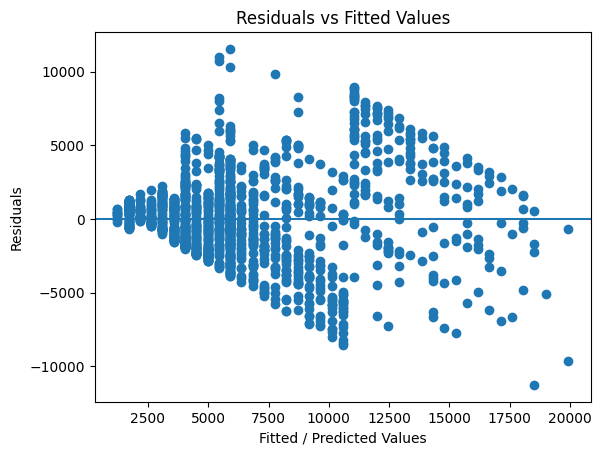

In [ ]:
plt.scatter(fitted_values, residuals)
plt.axhline(0)
plt.xlabel('Fitted / Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()


## 12. Normality of Residuals

For inference, we usually want the **residuals** to be approximately normal.

This does not mean the raw variables must be perfectly normal.


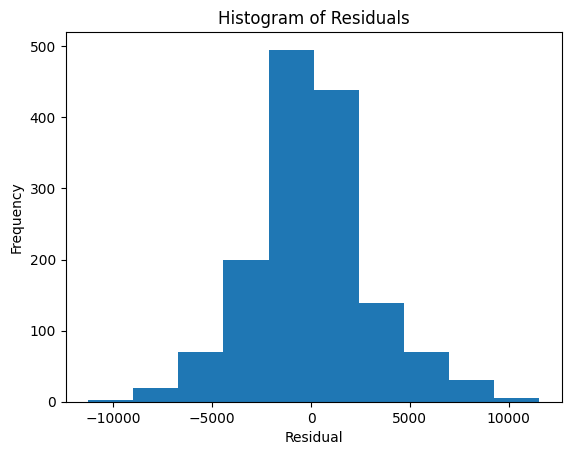

In [ ]:
plt.hist(residuals)
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()


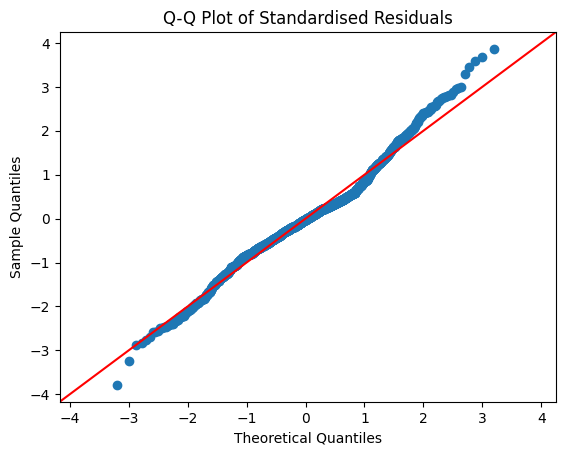

In [ ]:
# Q-Q plot using standardised residuals

influence = model.get_influence()
standardised_residuals = influence.resid_studentized_internal

sm.qqplot(standardised_residuals, line='45')
plt.title('Q-Q Plot of Standardised Residuals')
plt.show()


## 13. Independence of Errors

Independence means that one observation should not strongly depend on another.

For this HR dataset, the data is treated as cross-sectional employee-level data, so independence is mainly considered through the design and context.

Things that could weaken independence include:

- repeated measurements from the same person
- time-ordered data where one value depends on the previous value
- employees nested in teams where team effects are important

This notebook does not formally test independence. Learners should name it as an assumption and consider whether the data structure makes it reasonable.


## 14. Influential Points: Cook's Distance

An outlier is not always influential. An influential point is one that may strongly affect the regression line.

Cook's distance is one way to identify observations that may have a large influence on the model.

A common simple rule of thumb is to inspect observations with Cook's distance greater than `4 / N`.


In [ ]:
influence = model.get_influence()
cooks_distance = influence.cooks_distance[0]

diagnostic_data['CooksDistance'] = cooks_distance

threshold = 4 / n
print(f"Cook's distance inspection threshold: {threshold:.5f}")

potentially_influential = diagnostic_data[diagnostic_data['CooksDistance'] > threshold]

print(f"Number of observations above threshold: {len(potentially_influential)}")
display(potentially_influential.sort_values('CooksDistance', ascending=False).head(10))


Cook's distance inspection threshold: 0.00272
Number of observations above threshold: 139


,TotalWorkingYears,MonthlyIncome,PredictedMonthlyIncome,Residual,CooksDistance
85,37,7260,"18,531.297","-11,271.297",0.059
126,40,10312,"19,934.272","-9,622.272",0.053
1111,34,10169,"17,128.321","-6,959.321",0.018
624,35,10934,"17,595.980","-6,661.980",0.018
760,30,7525,"15,257.688","-7,732.688",0.016
98,38,13872,"18,998.955","-5,126.955",0.013
677,29,7403,"14,790.029","-7,387.029",0.013
890,33,10502,"16,660.663","-6,158.663",0.013
401,36,13212,"18,063.638","-4,851.638",0.010
63,28,7637,"14,322.371","-6,685.371",0.010


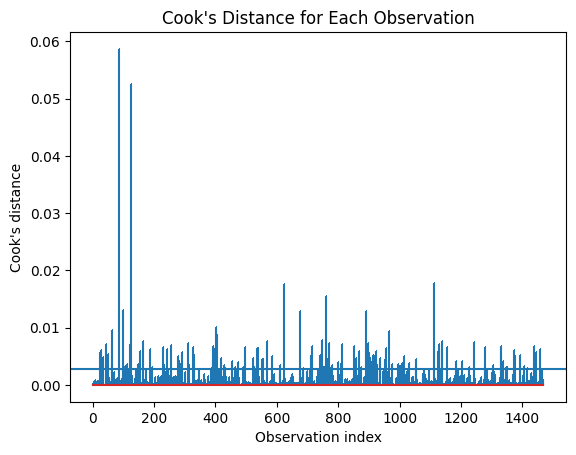

In [ ]:
plt.stem(np.arange(len(cooks_distance)), cooks_distance, markerfmt=',')
plt.axhline(threshold)
plt.xlabel('Observation index')
plt.ylabel("Cook's distance")
plt.title("Cook's Distance for Each Observation")
plt.show()


## 15. Prediction Error: MAE and RMSE

If regression is being used for prediction, it is useful to examine prediction error.

- **MAE** is the average absolute prediction error.
- **RMSE** is another error measure that gives more weight to larger errors.

These help learners think about how far predictions are from observed values.


In [ ]:
mae = mean_absolute_error(y, predicted_income)
rmse = np.sqrt(mean_squared_error(y, predicted_income))

error_table = pd.DataFrame({
    'Metric': ['Mean Absolute Error', 'Root Mean Squared Error'],
    'Value': [mae, rmse]
})

display(error_table)


,Metric,Value
0,Mean Absolute Error,"2,216.305"
1,Root Mean Squared Error,"2,986.352"


## 16. Make a Simple Estimate

This estimates MonthlyIncome for a hypothetical employee with a given number of total working years.

This is a **simple estimate from a one-variable model**, not a firm forecast or complete salary model.


In [ ]:
new_total_working_years = 10

new_data = pd.DataFrame({
    'const': [1],
    'TotalWorkingYears': [new_total_working_years]
})

prediction = model.predict(new_data)[0]

print(f'Estimated MonthlyIncome for {new_total_working_years} total working years: {prediction:,.2f}')


Estimated MonthlyIncome for 10 total working years: 5,904.52


## 17. Interpretation Helper

Keep the interpretation simple:

- the slope describes the expected change in the outcome for a one-unit change in the predictor
- the p-value gives evidence about whether the slope differs from zero
- R-squared gives the proportion of variance in the outcome explained by the model


In [ ]:
def interpret_regression(p_value, r2):
    if p_value < 0.05:
        evidence = 'evidence that the slope differs from zero in the sample'
    else:
        evidence = 'insufficient evidence that the slope differs from zero in the sample'

    return f'There is {evidence}. The model explains approximately {r2 * 100:.1f}% of the variance in MonthlyIncome.'

print(interpret_regression(p_value_slope, r_squared))


There is evidence that the slope differs from zero in the sample. The model explains approximately 59.7% of the variance in MonthlyIncome.


## 18. Cautious Reporting Template

In [ ]:
print(
    f'A simple linear regression was conducted to examine whether TotalWorkingYears predicted MonthlyIncome. '
    f'The slope coefficient was {b1:.2f}, meaning that each additional year of total working experience was associated '
    f'with an estimated {b1:.2f} increase in predicted monthly income on average. '
    f'The p-value for the slope was {p_value_slope:.5f}, which provides evidence about whether the slope differs from zero. '
    f'The model R-squared was {r_squared:.3f}, meaning that the model explains approximately {r_squared * 100:.1f}% '
    f'of the variance in MonthlyIncome. '
    f'This should be interpreted as an exploratory association, not proof that working years caused higher income, '
    f'as other factors may also influence monthly income.'
)


A simple linear regression was conducted to examine whether TotalWorkingYears predicted MonthlyIncome. The slope coefficient was 467.66, meaning that each additional year of total working experience was associated with an estimated 467.66 increase in predicted monthly income on average. The p-value for the slope was 0.00000, which provides evidence about whether the slope differs from zero. The model R-squared was 0.597, meaning that the model explains approximately 59.7% of the variance in MonthlyIncome. This should be interpreted as an exploratory association, not proof that working years caused higher income, as other factors may also influence monthly income.


## 19. Stretch Reflection Questions

1. When would regression be more suitable than correlation?
2. What does the slope coefficient tell you in plain English?
3. What does R-squared tell you about the model?
4. What does the p-value for the slope tell you?
5. Why do we check residuals rather than only looking at the raw variables?
6. What does the residuals vs fitted plot help us assess?
7. What does Cook's distance help us identify?
8. Why should this result not be interpreted as proof of causation?
9. Would this model alone be enough to make a business decision? Why / why not?
